In [ ]:
#Install Package
!pip install yfinance
!pip install yahoofinancials

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=ed26c53cb32e3552acfa497063b9f9e410fb0ec0d20bb96e249533f0d6651d17
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [ ]:
import yfinance as yf
from yahoofinancials import YahooFinancials

import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np
import plotly.graph_objects as go

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Step added because of Wikipedia blocking pandas user-agent
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
table = pd.read_html(response.text)[0]

# Creating a dictionary with the Symbol and Security columns

sp500_dict = dict(zip(table.iloc[:, 0], table.iloc[:, 1]))

# Extracting the ticker list

tickerlist = list(sp500_dict.keys())

/tmp/ipykernel_14710/1251342058.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)[0]


In [ ]:
sp500_dict

{'MMM': '3M',
 'AOS': 'A. O. Smith',
 'ABT': 'Abbott Laboratories',
 'ABBV': 'AbbVie',
 'ACN': 'Accenture',
 'ADBE': 'Adobe Inc.',
 'AMD': 'Advanced Micro Devices',
 'AES': 'AES Corporation',
 'AFL': 'Aflac',
 'A': 'Agilent Technologies',
 'APD': 'Air Products',
 'ABNB': 'Airbnb',
 'AKAM': 'Akamai Technologies',
 'ALB': 'Albemarle Corporation',
 'ARE': 'Alexandria Real Estate Equities',
 'ALGN': 'Align Technology',
 'ALLE': 'Allegion',
 'LNT': 'Alliant Energy',
 'ALL': 'Allstate',
 'GOOGL': 'Alphabet Inc. (Class A)',
 'GOOG': 'Alphabet Inc. (Class C)',
 'MO': 'Altria',
 'AMZN': 'Amazon',
 'AMCR': 'Amcor',
 'AEE': 'Ameren',
 'AEP': 'American Electric Power',
 'AXP': 'American Express',
 'AIG': 'American International Group',
 'AMT': 'American Tower',
 'AWK': 'American Water Works',
 'AMP': 'Ameriprise Financial',
 'AME': 'Ametek',
 'AMGN': 'Amgen',
 'APH': 'Amphenol',
 'ADI': 'Analog Devices',
 'AON': 'Aon plc',
 'APA': 'APA Corporation',
 'APO': 'Apollo Global Management',
 'AAPL': 'Ap

In [ ]:
tickerlist

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK.B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF.B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'C

In [ ]:
# Define a start date and End Date
start = '2022-01-01'
end = '2025-01-01'

In [ ]:
df = yf.download(tickers=tickerlist, start= start , end = end)

/tmp/ipykernel_14710/29310503.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers=tickerlist, start= start , end = end)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


In [ ]:
df

Price      Adj Close                      Close                          \
Ticker          BF.B BRK.B   Q SNDK           A        AAPL        ABBV   
Date                                                                      
2022-01-03       NaN   NaN NaN  NaN  151.702148  178.103653  115.847206   
2022-01-04       NaN   NaN NaN  NaN  146.573700  175.843262  115.624794   
2022-01-05       NaN   NaN NaN  NaN  144.062759  171.165833  116.232170   
2022-01-06       NaN   NaN NaN  NaN  144.566879  168.308487  115.684685   
2022-01-07       NaN   NaN NaN  NaN  140.718079  168.474838  115.385262   
...              ...   ...  ..  ...         ...         ...         ...   
2024-12-24       NaN   NaN NaN  NaN  134.457245  256.797211  172.530670   
2024-12-26       NaN   NaN NaN  NaN  134.190521  257.612732  171.763855   
2024-12-27       NaN   NaN NaN  NaN  133.904007  254.201370  170.623245   
2024-12-30       NaN   NaN NaN  NaN  132.797531  250.829788  168.888351   
2024-12-31       NaN   NaN NaN  NaN  132.963806  249.059464  170.326126   

Price                                          ...   Volume                    \
Ticker            ABNB         ABT       ACGL  ...       WY     WYNN      XEL   
Date                                           ...                              
2022-01-03  172.679993  128.345993  42.362530  ...  3831100  2437800  3501100   
2022-01-04  170.800003  125.327522  42.914051  ...  3089700  2292300  4197000   
2022-01-05  162.250000  124.764412  42.410072  ...  3737600  3439900  4166000   
2022-01-06  159.750000  124.745941  42.657307  ...  3315200  2583200  2296000   
2022-01-07  166.050003  125.133636  42.856995  ...  3309900  1720400  2673100   
...                ...         ...        ...  ...      ...      ...      ...   
2024-12-24  134.990005  112.058289  92.669998  ...  1780100   692800   943900   
2024-12-26  135.320007  112.556282  92.930000  ...  1736500  1218900  1394900   
2024-12-27  133.384995  112.282867  92.339996  ...  2320500  1086700  2015000   
2024-12-30  131.809998  110.144440  91.889999  ...  2914700  2180100  2642900   
2024-12-31  131.410004  110.447136  92.349998  ...  3125200  1612600  2143800   

Price                                                                       
Ticker           XOM      XYL       XYZ      YUM      ZBH    ZBRA      ZTS  
Date                                                                        
2022-01-03  24282400   759100   7315700  1251400  1184809  272600  2772700  
2022-01-04  38584000   925400  14768500   935900  1400800  346000  4664000  
2022-01-05  34033300  1090200  17546200   977900  1895715  403700  4749400  
2022-01-06  30668500   703400  16244200   862400  1088813  338300  3103400  
2022-01-07  23985400   765000   9426000   833700  1690230  432800  2206500  
...              ...      ...       ...      ...      ...     ...      ...  
2024-12-24   7807000   379300   2197700   533000   458600   88700  1023600  
2024-12-26   9652400   575700   2991100  1040900  1277300  140100  2167200  
2024-12-27  11943900   552400   4140800  1146300   743400  287200  1800100  
2024-12-30  11080800   586800   5383800  1144600  1532000  211300  1531400  
2024-12-31  12387800   641600   4989400  1217100   683300  327900  1327400  

[753 rows x 2519 columns]

In [ ]:
df.describe()

Price  Adj Close                       Close                          \
Ticker      BF.B BRK.B    Q SNDK           A        AAPL        ABBV   
count        0.0   0.0  0.0  0.0  753.000000  753.000000  753.000000   
mean         NaN   NaN  NaN  NaN  130.064351  176.028012  144.169004   
std          NaN   NaN  NaN  NaN   11.427631   29.480789   19.260842   
min          NaN   NaN  NaN  NaN   99.275681  123.046806  114.075989   
25%          NaN   NaN  NaN  NaN  122.859200  153.404892  129.996765   
50%          NaN   NaN  NaN  NaN  130.553528  171.187973  138.039398   
75%          NaN   NaN  NaN  NaN  137.322235  189.590439  157.459518   
max          NaN   NaN  NaN  NaN  155.217911  257.612732  195.410141   

Price                                       ...        Volume                \
Ticker        ABNB         ABT        ACGL  ...            WY          WYNN   
count   753.000000  753.000000  753.000000  ...  7.530000e+02  7.530000e+02   
mean    130.588958  103.725511   69.860612  ...  3.893122e+06  2.591136e+06   
std      20.996819    7.348765   20.305283  ...  1.592697e+06  1.590913e+06   
min      82.489998   86.343636   39.623940  ...  9.679000e+05  6.928000e+05   
25%     115.940002   98.686081   45.861835  ...  2.965000e+06  1.628700e+06   
50%     129.699997  102.849228   70.984573  ...  3.581300e+06  2.180100e+06   
75%     146.699997  109.288406   86.826546  ...  4.446600e+06  2.983000e+06   
max     186.639999  128.345993  109.220207  ...  1.834140e+07  1.505450e+07   

Price                                                                         \
Ticker           XEL           XOM           XYL           XYZ           YUM   
count   7.530000e+02  7.530000e+02  7.530000e+02  7.530000e+02  7.530000e+02   
mean    3.640352e+06  1.969823e+07  1.352194e+06  1.245447e+07  1.760692e+06   
std     1.980737e+06  8.634727e+06  1.080534e+06  8.550124e+06  6.757253e+05   
min     9.439000e+05  7.136000e+06  3.211000e+05  2.197700e+06  5.330000e+05   
25%     2.545100e+06  1.397380e+07  8.997000e+05  7.605600e+06  1.330000e+06   
50%     3.173400e+06  1.743320e+07  1.144400e+06  1.055780e+07  1.618100e+06   
75%     4.139200e+06  2.241530e+07  1.533100e+06  1.489760e+07  2.017300e+06   
max     2.278220e+07  7.208230e+07  2.024170e+07  1.403139e+08  7.448300e+06   

Price                                             
Ticker           ZBH          ZBRA           ZTS  
count   7.530000e+02  7.530000e+02  7.530000e+02  
mean    1.482036e+06  4.021021e+05  2.221513e+06  
std     7.254535e+05  2.082815e+05  1.059138e+06  
min     4.279000e+05  8.870000e+04  6.352000e+05  
25%     1.030800e+06  2.766000e+05  1.560900e+06  
50%     1.317600e+06  3.554000e+05  1.951100e+06  
75%     1.726300e+06  4.785000e+05  2.540900e+06  
max     7.107800e+06  2.621700e+06  1.157780e+07  

[8 rows x 2519 columns]

In [ ]:
df = df.drop(columns='Adj Close')

**Identifying and removing invalid data**

In [ ]:
print("Shape before cleaning:", df.shape)
print("Missing values per column (sample):")
print(df.isnull().sum().sum(), "total missing values")

# Drop ticker columns where more than 50% of values are missing
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=int(threshold))

# Forward fill remaining missing values (carries last known price forward)
df = df.ffill()

# Drop any remaining rows with NaN
df = df.dropna()

print("Shape after cleaning:", df.shape)

Shape before cleaning: (753, 2519)
Missing values per column (sample):
28797 total missing values
Shape after cleaning: (418, 2480)


In [ ]:
df

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2023-05-04  130.859009  163.422485  133.434296  117.629997  105.044067   
2023-05-05  130.292114  171.091385  134.040955  119.900002  105.423080   
2023-05-08  129.461258  171.022385  133.515747  125.650002  105.081963   
2023-05-09  124.476341  169.317078  132.954361  127.070000  104.466064   
2023-05-10  125.170319  171.081528  132.583115  113.190002  104.882980   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457245  256.797211  172.530670  134.990005  112.058289   
2024-12-26  134.190521  257.612732  171.763855  135.320007  112.556282   
2024-12-27  133.904007  254.201370  170.623245  133.384995  112.282867   
2024-12-30  132.797531  250.829788  168.888351  131.809998  110.144440   
2024-12-31  132.963806  249.059464  170.326126  131.410004  110.447136   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2023-05-04  69.339516  256.592438  335.829987  172.395767  67.246979  ...   
2023-05-05  71.136719  255.774017  348.399994  174.354233  68.823502  ...   
2023-05-08  72.401413  254.974869  344.059998  175.428604  68.316109  ...   
2023-05-09  72.848335  253.684723  342.649994  170.770020  67.971809  ...   
2023-05-10  73.428383  258.893555  344.019989  172.490814  67.627502  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  356.539642  447.940002  213.882050  48.364082  ...   
2024-12-26  92.930000  355.356537  450.160004  213.852631  48.344978  ...   
2024-12-27  92.339996  351.166321  446.480011  212.803268  48.316322  ...   
2024-12-30  91.889999  347.528290  445.799988  208.458755  47.829144  ...   
2024-12-31  92.349998  346.838165  444.679993  208.360687  48.259010  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2023-05-04  3873700  1644000  3463900  17177200  2583600  16023900  1555600   
2023-05-05  3053300  1561100  2147900  14968200  2884900  25485600  1361600   
2023-05-08  3942900  1836700  2171000  11187800  1523300  13623600   981400   
2023-05-09  5347400  3359700  2102800  11370800  1452700   8377200  1094900   
2023-05-10  4935700  5041500  2963100  14884800  1344700  12457000  1595200   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2023-05-04  1410500  551700  3592200  
2023-05-05   995900  486300  4224400  
2023-05-08  1304500  384100  1976100  
2023-05-09  1017600  432900  1904200  
2023-05-10  1163400  257400  1610500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[418 rows x 2480 columns]

In [ ]:
df.to_csv('S&P500.csv')

In [ ]:
stock_open = np.array(df['Open']).T # stock_open is numpy array of transpose of p['Open']
stock_close = np.array(df['Close']).T # stock_close is numpy array of transpose of p['Close']

In [ ]:
movements = stock_close - stock_open
movements

array([[-1.46615257, -1.95487039, -1.52479616, ...,  0.90889366,
         0.01976282, -0.46518649],
       [ 0.88714184,  2.55302559,  1.0054384 , ..., -2.22782032,
        -0.0298358 , -2.00902957],
       [-1.48501739, -0.4617993 , -0.63384617, ...,  0.08626183,
        -0.78598007,  1.29397138],
       ...,
       [-1.78137391,  0.73981425,  0.21415525, ...,  0.41383974,
        -0.64190052, -0.27651665],
       [ 8.79998779,  4.69998169,  3.85998535, ..., -4.29998779,
        -1.20999146,  2.79998779],
       [10.14121811,  6.03435893, -1.39478293, ..., -0.34393221,
        -1.62143105,  0.02947948]])

In [ ]:
sum_of_movement = np.sum(movements,1)

for i in range(len(sum_of_movement)):
  print('company:{}, Change:{}'.format(df['High'].columns[i],sum_of_movement[i]))

company:A, Change:4.590537173715717
company:AAPL, Change:89.11212764196526
company:ABBV, Change:17.38538008891834
company:ABNB, Change:80.47412872314453
company:ABT, Change:3.9852908130080067
company:ACGL, Change:-27.700382202889003
company:ACN, Change:77.80277947499457
company:ADBE, Change:84.149658203125
company:ADI, Change:3.998273736966695
company:ADM, Change:-13.04063065529617
company:ADP, Change:-1.1147272730819395
company:ADSK, Change:78.82014465332031
company:AEE, Change:-5.69396233779959
company:AEP, Change:-6.613704418807245
company:AES, Change:-12.624910863978082
company:AFL, Change:16.357031699181746
company:AIG, Change:1.371285546181035
company:AIZ, Change:13.450074886650455
company:AJG, Change:16.371286113546773
company:AKAM, Change:2.5399627685546875
company:ALB, Change:-115.10114105063342
company:ALGN, Change:-101.0699462890625
company:ALL, Change:-11.082800589114115
company:ALLE, Change:-0.39283917802563906
company:AMAT, Change:-41.59030434838476
company:AMCR, Change:-

In [ ]:
daily_returns = (df["Close"] - df["Close"].shift(1)) / df["Close"].shift(1)

In [ ]:
daily_returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05-05,-0.004332,0.046927,0.004546,0.019298,0.003608,0.025919,-0.003190,0.037430,0.011360,0.023444,...,0.022751,0.014004,0.006656,0.024896,0.024828,-0.019527,0.008583,0.009368,0.033208,0.043481
2023-05-08,-0.006377,-0.000403,-0.003918,0.047957,-0.003236,0.017778,-0.003124,-0.012457,0.006162,-0.007372,...,0.002696,0.017873,-0.003593,0.003957,-0.014958,-0.007595,-0.006982,-0.003408,0.014828,-0.007303
2023-05-09,-0.038505,-0.009971,-0.004205,0.011301,-0.005861,0.006173,-0.005060,-0.004098,-0.026555,-0.005040,...,0.007059,-0.009401,-0.003029,0.000275,-0.005031,0.008844,0.007910,-0.010114,-0.027712,-0.002705
2023-05-10,0.005575,0.010421,-0.002792,-0.109231,0.003991,0.007962,0.020533,0.003998,0.010077,-0.005065,...,0.004673,-0.001790,0.002749,-0.012827,0.000094,-0.030175,0.000945,0.010070,0.005959,0.004176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011144,0.011478,0.009025,0.003494,0.003937,0.006298,0.007972,0.002686,0.014891,0.004364,...,0.006410,0.007604,0.007236,0.000941,0.005446,0.020047,0.008516,0.004494,0.012262,0.002557
2024-12-26,-0.001984,0.003176,-0.004445,0.002445,0.004444,0.002806,-0.003318,0.004956,-0.000138,-0.000395,...,-0.003185,0.005970,-0.000440,0.000846,0.002708,0.004392,0.007408,-0.000466,0.003566,0.004979
2024-12-27,-0.002135,-0.013242,-0.006641,-0.014300,-0.002429,-0.006349,-0.011792,-0.008175,-0.004907,-0.000593,...,-0.006390,-0.007054,-0.000587,-0.000094,-0.007935,-0.027438,-0.005662,-0.003543,-0.019604,-0.005558


**Calculating BETA**

In [ ]:
index = yf.download('^GSPC', start=start, end=end)['Close'].squeeze()
index_returns = index.pct_change().dropna()
index_returns.name = 'GSPC'

betas = {}
for ticker in tickerlist:
    if ticker not in daily_returns.columns:
        continue
    stock_returns = daily_returns[ticker].dropna()
    aligned = pd.concat([stock_returns, index_returns], axis=1, join='inner').dropna()
    cov_matrix = np.cov(aligned[ticker], aligned['GSPC'])
    beta = cov_matrix[0, 1] / np.var(aligned['GSPC'])
    betas[ticker] = beta

betas_df = pd.Series(betas, name='Beta').to_frame()

/tmp/ipykernel_14710/1883923022.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  index = yf.download('^GSPC', start=start, end=end)['Close'].squeeze()
[*********************100%***********************]  1 of 1 completed


In [ ]:
betas_df

,Beta
MMM,0.872529
AOS,0.852688
ABT,0.261882
ABBV,0.238554
ACN,0.774229
...,...
XYL,0.984841
YUM,0.537992
ZBRA,1.416668
ZBH,0.579352


**Calculating Anual Volatility**

In [ ]:
annual_volatility = daily_returns.std() * np.sqrt(252)
annual_volatility_df = annual_volatility.to_frame(name='Annual Volatility')

In [ ]:
annual_volatility_df

,Annual Volatility
Ticker,
A,0.262364
AAPL,0.211885
ABBV,0.216108
ABNB,0.356680
ABT,0.179846
...,...
XYZ,0.473401
YUM,0.161240
ZBH,0.215355


**Illustration of metrics** (following method shown in lecture/seminar)

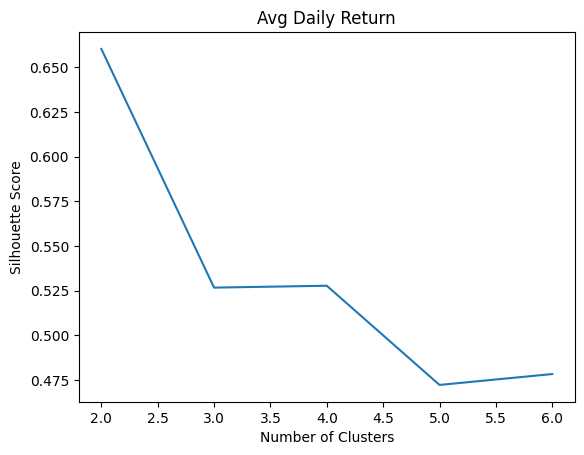

Cluster 1 has 458 observations
Cluster 2 has 38 observations


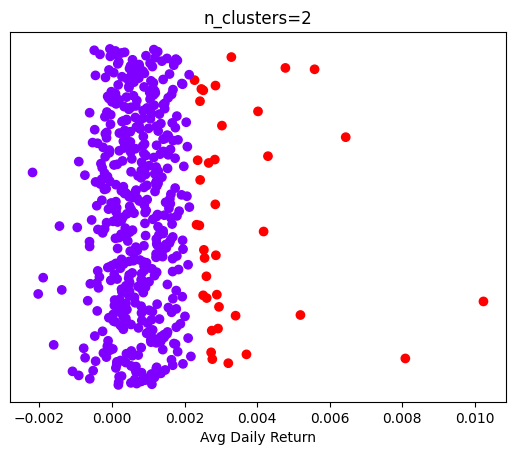

Cluster 1 has 38 observations
Cluster 2 has 281 observations
Cluster 3 has 177 observations


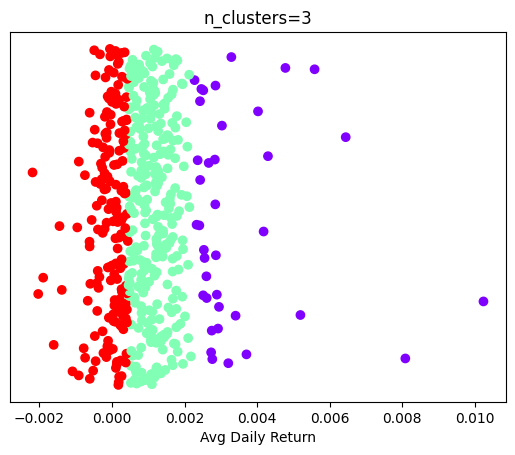

Cluster 1 has 281 observations
Cluster 2 has 36 observations
Cluster 3 has 177 observations
Cluster 4 has 2 observations


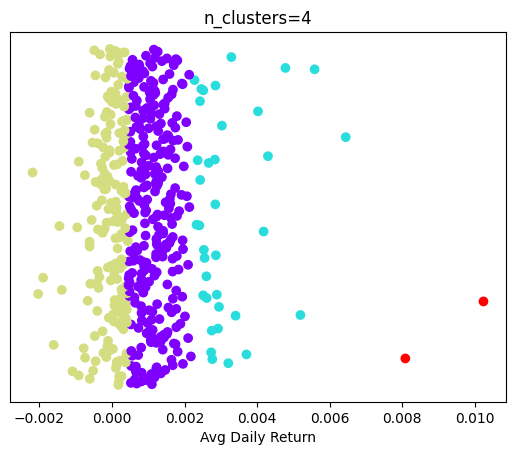

Cluster 1 has 36 observations
Cluster 2 has 160 observations
Cluster 3 has 177 observations
Cluster 4 has 2 observations
Cluster 5 has 121 observations


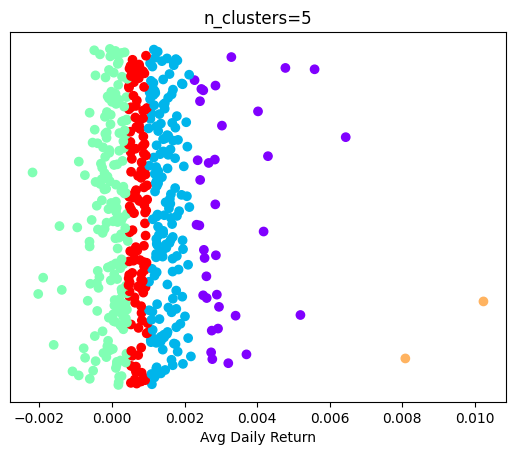

Cluster 1 has 177 observations
Cluster 2 has 160 observations
Cluster 3 has 7 observations
Cluster 4 has 2 observations
Cluster 5 has 121 observations
Cluster 6 has 29 observations


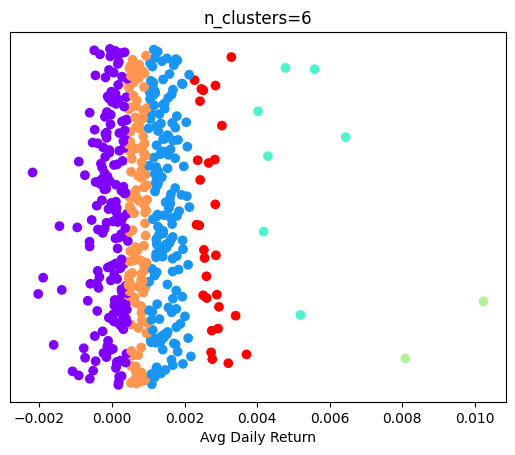

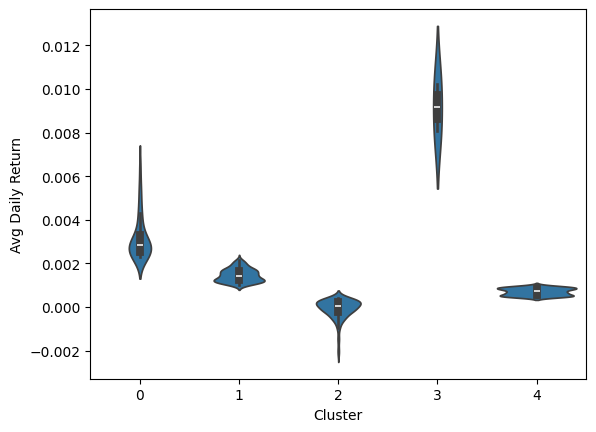

In [ ]:
# Daily Return

daily_returns_mean = daily_returns.mean().to_frame(name='Avg Daily Return').dropna()
X = daily_returns_mean[['Avg Daily Return']]
range_n_clusters = [2, 3, 4, 5, 6]

scores = []
for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit(X).labels_
    scores.append(silhouette_score(X, labels))

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Avg Daily Return')
plt.show()

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    plt.scatter(X, daily_returns_mean.index, c=labels, cmap='rainbow')
    plt.xlabel('Avg Daily Return')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
daily_returns_mean['Cluster'] = agglom.fit_predict(X)

sns.violinplot(x='Cluster', y='Avg Daily Return', data=daily_returns_mean)
plt.show()

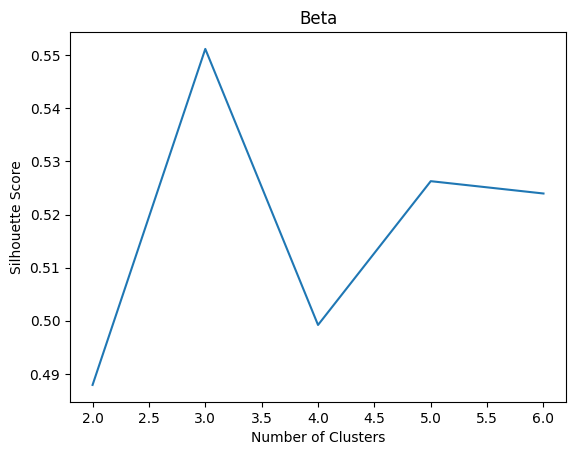

Cluster 1 has 291 observations
Cluster 2 has 205 observations


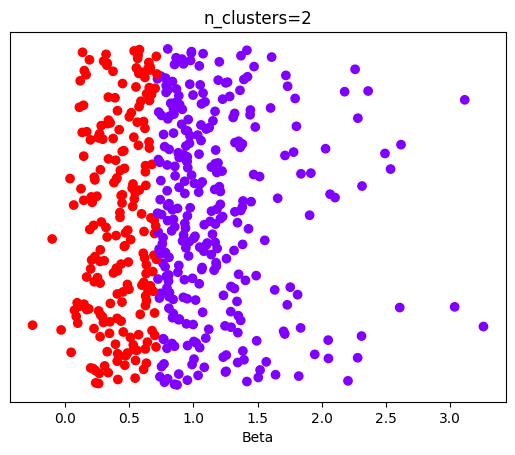

Cluster 1 has 247 observations
Cluster 2 has 205 observations
Cluster 3 has 44 observations


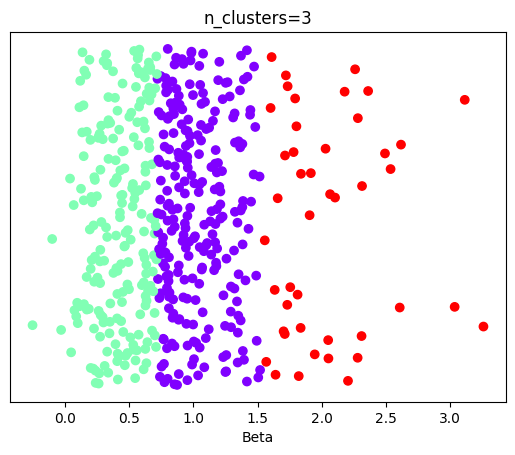

Cluster 1 has 205 observations
Cluster 2 has 111 observations
Cluster 3 has 44 observations
Cluster 4 has 136 observations


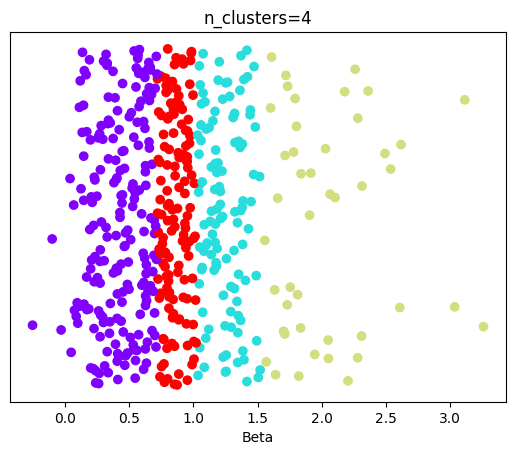

Cluster 1 has 44 observations
Cluster 2 has 111 observations
Cluster 3 has 125 observations
Cluster 4 has 136 observations
Cluster 5 has 80 observations


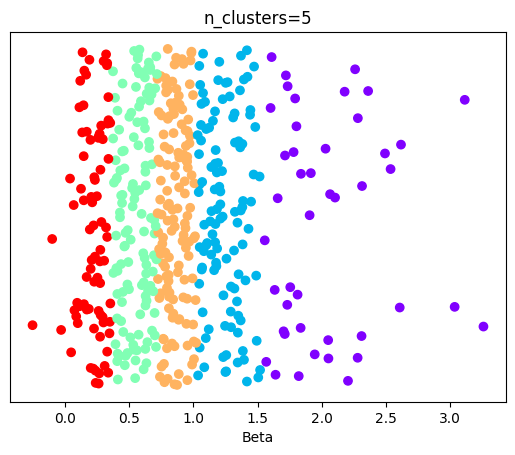

Cluster 1 has 20 observations
Cluster 2 has 111 observations
Cluster 3 has 125 observations
Cluster 4 has 136 observations
Cluster 5 has 80 observations
Cluster 6 has 24 observations


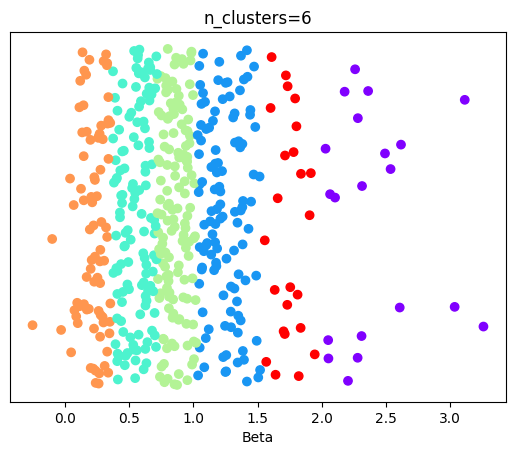

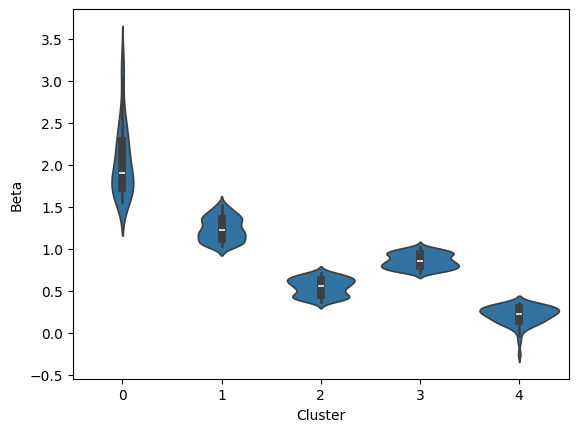

In [ ]:
# BETA

X = betas_df[['Beta']].dropna()
range_n_clusters = [2, 3, 4, 5, 6]

scores = []
for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit(X).labels_
    scores.append(silhouette_score(X, labels))

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Beta')
plt.show()

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    plt.scatter(X, X.index, c=labels, cmap='rainbow')
    plt.xlabel('Beta')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
X['Cluster'] = agglom.fit_predict(X)

sns.violinplot(x='Cluster', y='Beta', data=X)
plt.show()

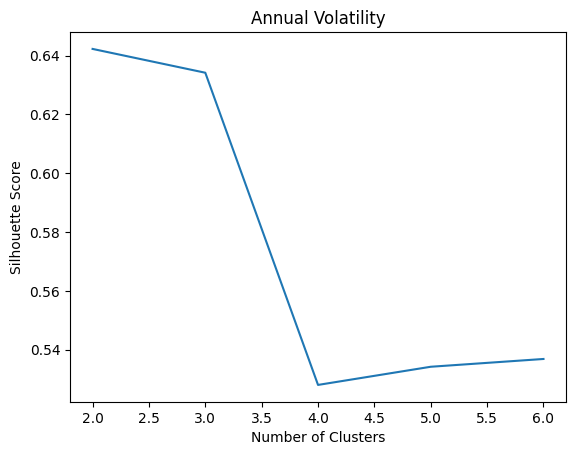

Cluster 1 has 108 observations
Cluster 2 has 388 observations


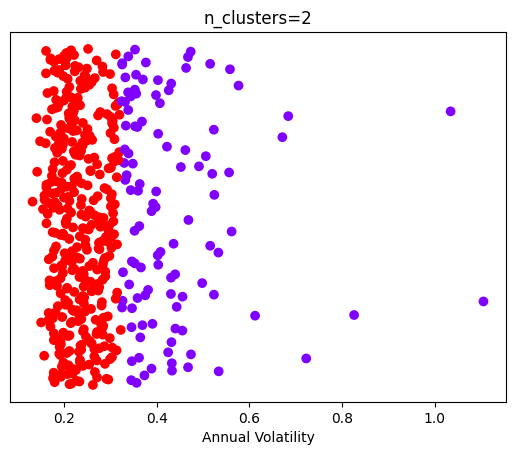

Cluster 1 has 388 observations
Cluster 2 has 102 observations
Cluster 3 has 6 observations


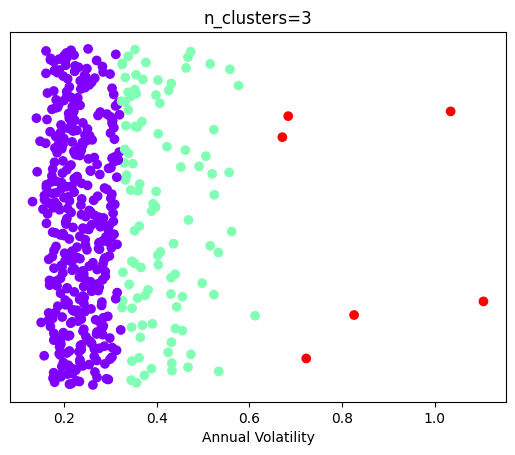

Cluster 1 has 102 observations
Cluster 2 has 202 observations
Cluster 3 has 6 observations
Cluster 4 has 186 observations


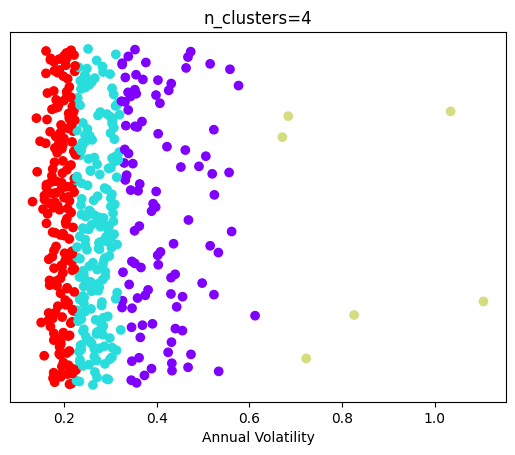

Cluster 1 has 6 observations
Cluster 2 has 202 observations
Cluster 3 has 39 observations
Cluster 4 has 186 observations
Cluster 5 has 63 observations


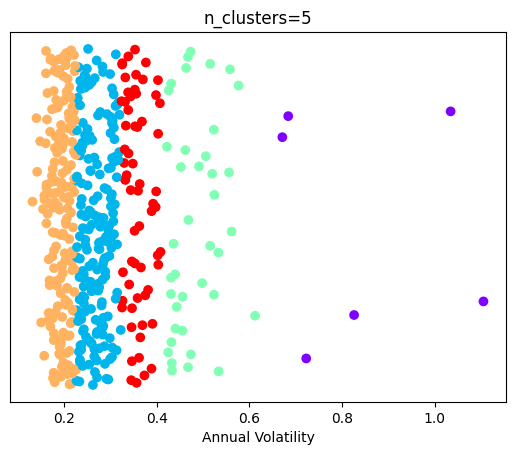

Cluster 1 has 202 observations
Cluster 2 has 186 observations
Cluster 3 has 39 observations
Cluster 4 has 4 observations
Cluster 5 has 63 observations
Cluster 6 has 2 observations


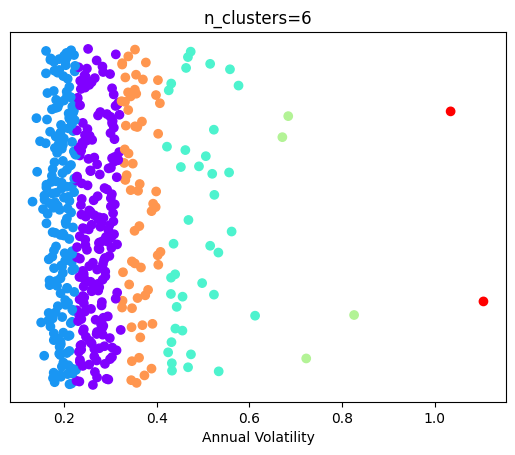

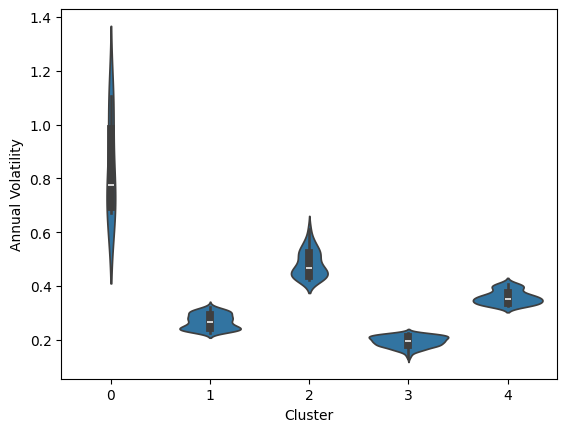

In [ ]:
# Annual Volatility

X = annual_volatility_df[['Annual Volatility']].dropna()
range_n_clusters = [2, 3, 4, 5, 6]

scores = []
for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agglom.fit(X).labels_
    scores.append(silhouette_score(X, labels))

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Annual Volatility')
plt.show()

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    plt.scatter(X, X.index, c=labels, cmap='rainbow')
    plt.xlabel('Annual Volatility')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
X['Cluster'] = agglom.fit_predict(X)

sns.violinplot(x='Cluster', y='Annual Volatility', data=X)
plt.show()

The three metrics — Daily Return, Beta, and Annual Volatility — are essential tools for investors seeking to balance risk and reward in a stock portfolio.

Daily Return measures how much a stock gains or loses each day relative to its previous price. Stocks with consistently higher average daily returns are more attractive to growth-oriented investors, while those with lower or negative returns may signal underperformance.

Beta measures a stock's sensitivity to market movements relative to the S&P 500 benchmark. A beta greater than 1 indicates the stock is more volatile than the market, making it riskier but potentially more rewarding. A beta below 1 suggests the stock is more stable and less affected by market swings, making it suitable for risk-averse investors.

Annual Volatility quantifies the degree of price fluctuation over a year. High volatility stocks carry greater uncertainty and risk, while low volatility stocks offer more predictable, stable returns.

By clustering stocks using these three metrics with agglomerative clustering, investors can identify natural groupings — for example, a cluster of low-beta, low-volatility stocks suitable for conservative portfolios, versus a cluster of high-beta, high-return stocks suited for aggressive growth strategies. This segmentation enables investors to build diversified portfolios that align with their specific risk tolerance.